In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("powerplant_data.csv")

In [21]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT=> temperature
#v=>vaccum
# AP=>pressure
#RH=>humidity
#PE=> produce energy

In [22]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [3]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [4]:
#split out data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y, test_size=0.2,random_state=42
)

In [10]:
df.shape

(9568, 5)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [12]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [6]:
import torch
import torch.nn as nn
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [7]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [8]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

### Deep Learning

In [9]:
# Define our ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #Output Layer
            nn.Linear(6,1)
            
        )
      
    

    def forward(self,x):
        return self.model(x)
        

In [10]:
import torch.optim as optim
model=ANN()

# loss,optimizer
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [11]:
# Train the ANN
train_losses=[]
val_losses=[]
best_val_loss=float("inf")
epochs=100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0  # total training loss for 1 epoch

    for xb, yb in train_loader:
        
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        outputs = model(xb) # forward prop......predicted outputs for this batch
        loss=crietrion(outputs,yb) # compute loss
        loss.backward() # back prop.... compute gradients
        optimizer.step() # parameters update
        running_loss+=loss.item() # loss is a tensor value convert to python float
    
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs=model(xb)
            loss=crietrion(outputs, yb)
            running_val_loss+=loss
            
    epoch_val_loss=running_loss/len(test_loader)
    val_losses.append(epoch_val_loss)
    print(f"epoch {epoch+1}/{epochs} ==> training loss = {epoch_train_loss} & val loss = {epoch_val_loss}")


    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")  # to save model parameter form of .pt or .pth
        
        

epoch 1/100 ==> training loss = 206276.28932291668 & val loss = 825105.1572916667
epoch 2/100 ==> training loss = 199212.2482421875 & val loss = 796848.99296875
epoch 3/100 ==> training loss = 171524.41536458334 & val loss = 686097.6614583334
epoch 4/100 ==> training loss = 113423.68453776042 & val loss = 453694.7381510417
epoch 5/100 ==> training loss = 53626.13392740885 & val loss = 214504.5357096354
epoch 6/100 ==> training loss = 23543.861702473958 & val loss = 94175.44680989583
epoch 7/100 ==> training loss = 15153.44516398112 & val loss = 60613.78065592448
epoch 8/100 ==> training loss = 12033.225018310546 & val loss = 48132.900073242185
epoch 9/100 ==> training loss = 9582.19867960612 & val loss = 38328.79471842448
epoch 10/100 ==> training loss = 7313.11034749349 & val loss = 29252.44138997396
epoch 11/100 ==> training loss = 5366.012781778972 & val loss = 21464.051127115887
epoch 12/100 ==> training loss = 3754.4272598266602 & val loss = 15017.709039306641
epoch 13/100 ==> tra

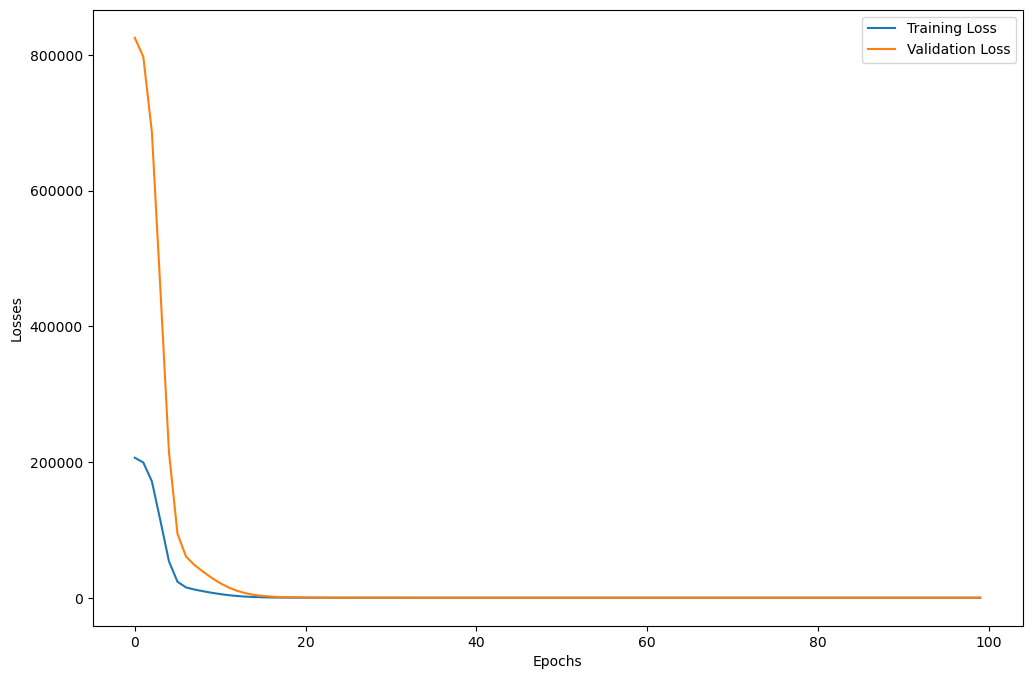

In [12]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss":val_losses
})
plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [13]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [14]:
# Evaluation our Model

model.eval()
with torch.no_grad():
    
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)
    train_mse_loss = crietrion(train_preds,y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing Mse:",test_mse_loss.item())
    
    

Training MSE: 20.489973068237305
Testing Mse: 19.028268814086914


In [15]:
from sklearn.metrics import r2_score

print("r2 score=",r2_score(y_test,test_preds))

r2 score= 0.9335011138417942


In [16]:
predicted_df = pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values,columns=["Actual Values"])
pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.796173,433.27
1,436.987457,438.16
2,462.339264,458.42
3,476.946320,480.82
4,436.315033,441.41
...,...,...
1909,451.570404,456.70
1910,431.971436,438.04
1911,467.960419,467.80
1912,431.347687,437.14
